Dhaivat Jani <br>
202511053 <br>
Lab 04 - Object Detection

# Preparation: Ground Truth Visualization

In [ ]:
import os
import glob

DATASET_ROOT = r"D:\College\DAU\Sem 02\Deep Learning\Lab04\Fruit Images for Object Detection"

# Find all images recursively
all_images = glob.glob(os.path.join(DATASET_ROOT, "**", "*.jpg"), recursive=True)
all_images += glob.glob(os.path.join(DATASET_ROOT, "**", "*.png"), recursive=True)

# Find all XML annotation files
all_annotations = glob.glob(os.path.join(DATASET_ROOT, "**", "*.xml"), recursive=True)

print(f"Total images found     : {len(all_images)}")
print(f"Total annotations found: {len(all_annotations)}")

# Separate train and test images
train_images = [p for p in all_images if "train" in p]
test_images  = [p for p in all_images if "test"  in p]

print(f"\nTrain images: {len(train_images)}")
print(f"Test images : {len(test_images)}")

Total images found     : 300
Total annotations found: 300

Train images: 240
Test images : 60


In [ ]:
import xml.etree.ElementTree as ET

def parse_xml_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes = []
    for obj in root.findall("object"):
        label = obj.find("name").text
        bndbox = obj.find("bndbox")
        xmin = int(float(bndbox.find("xmin").text))
        ymin = int(float(bndbox.find("ymin").text))
        xmax = int(float(bndbox.find("xmax").text))
        ymax = int(float(bndbox.find("ymax").text))
        boxes.append({"label": label, "xmin": xmin, "ymin": ymin,
                       "xmax": xmax, "ymax": ymax})
    return boxes

In [ ]:
def find_annotation_for_image(img_path, all_xml_files):
    stem = os.path.splitext(os.path.basename(img_path))[0]

    for xml in all_xml_files:
        if os.path.splitext(os.path.basename(xml))[0] == stem:
            return xml
        
    return None

In [27]:
import random
import cv2

random.seed(42)
sample_img_path = None
sample_xml_path = None

for img in random.sample(train_images, len(train_images)):
    xml = find_annotation_for_image(img, all_annotations)
    if xml:
        sample_img_path = img
        sample_xml_path = xml
        break

print(f"Selected image     : {sample_img_path}")
print(f"Annotation file    : {sample_xml_path}")

# ─── Load image and annotations ───
img_bgr  = cv2.imread(sample_img_path)
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gt_boxes = parse_xml_annotation(sample_xml_path)
print(f"Ground-truth boxes : {gt_boxes}")

Selected image     : D:\College\DAU\Sem 02\Deep Learning\Lab04\Fruit Images for Object Detection\train\mixed_5.jpg
Annotation file    : D:\College\DAU\Sem 02\Deep Learning\Lab04\Fruit Images for Object Detection\train\mixed_5.xml
Ground-truth boxes : [{'label': 'orange', 'xmin': 556, 'ymin': 178, 'xmax': 950, 'ymax': 559}, {'label': 'apple', 'xmin': 73, 'ymin': 164, 'xmax': 474, 'ymax': 550}, {'label': 'banana', 'xmin': 177, 'ymin': 604, 'xmax': 858, 'ymax': 966}]


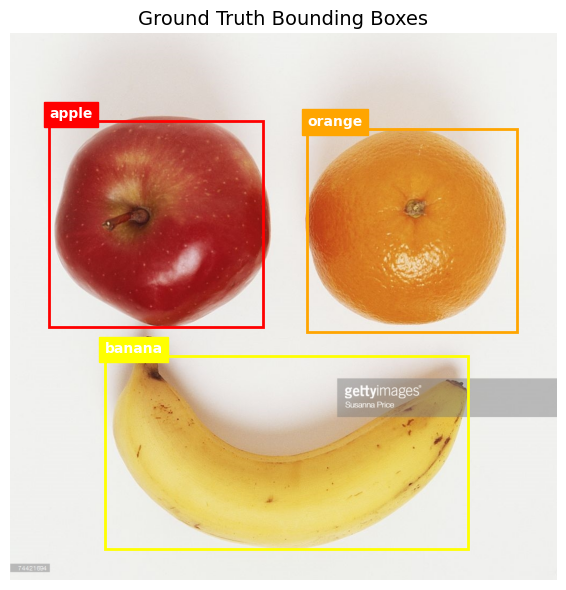

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

CLASS_COLORS = {"apple": "red", "banana": "yellow", "orange": "orange"}

fig, ax = plt.subplots(1, figsize=(8, 6))
ax.imshow(img_rgb)

for box in gt_boxes:
    x, y  = box["xmin"], box["ymin"]
    w     = box["xmax"] - box["xmin"]
    h     = box["ymax"] - box["ymin"]
    color = CLASS_COLORS.get(box["label"].lower(), "cyan")

    rect = patches.Rectangle((x, y), w, h,
                              linewidth=2, edgecolor=color, facecolor="none")
    ax.add_patch(rect)
    ax.text(x, y - 5, box["label"], fontsize=10,
            color="white", backgroundcolor=color, fontweight="bold")

ax.set_title("Ground Truth Bounding Boxes", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

# Task 1 - Core Concept: Intersection over Union (IoU) 

In [ ]:
def compute_iou(box_a, box_b):
    # Coordinates of the intersection rectangle
    inter_xmin = max(box_a[0], box_b[0])
    inter_ymin = max(box_a[1], box_b[1])
    inter_xmax = min(box_a[2], box_b[2])
    inter_ymax = min(box_a[3], box_b[3])

    # Intersection area (0 if no overlap)
    inter_w = max(0, inter_xmax - inter_xmin)
    inter_h = max(0, inter_ymax - inter_ymin)
    intersection = inter_w * inter_h

    # Individual box areas
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])

    # Union area
    union = area_a + area_b - intersection

    if union == 0:
        return 0.0

    return round(intersection / union, 4)

In [7]:
# ─── Demonstration with 3 test cases ───
print("=" * 50)
print("IoU Demonstration")
print("=" * 50)

# Case 1: Highly overlapping boxes
b1, b2 = [10, 10, 100, 100], [15, 15, 105, 105]
print(f"\n[Case 1] Highly overlapping")
print(f"  Box A : {b1}")
print(f"  Box B : {b2}")
print(f"  IoU   : {compute_iou(b1, b2)}")

# Case 2: Partially overlapping boxes
b3, b4 = [0, 0, 50, 50], [30, 30, 80, 80]
print(f"\n[Case 2] Partially overlapping")
print(f"  Box A : {b3}")
print(f"  Box B : {b4}")
print(f"  IoU   : {compute_iou(b3, b4)}")

# Case 3: Completely disjoint boxes
b5, b6 = [0, 0, 40, 40], [60, 60, 100, 100]
print(f"\n[Case 3] Completely disjoint")
print(f"  Box A : {b5}")
print(f"  Box B : {b6}")
print(f"  IoU   : {compute_iou(b5, b6)}")
print("=" * 50)

IoU Demonstration

[Case 1] Highly overlapping
  Box A : [10, 10, 100, 100]
  Box B : [15, 15, 105, 105]
  IoU   : 0.805

[Case 2] Partially overlapping
  Box A : [0, 0, 50, 50]
  Box B : [30, 30, 80, 80]
  IoU   : 0.087

[Case 3] Completely disjoint
  Box A : [0, 0, 40, 40]
  Box B : [60, 60, 100, 100]
  IoU   : 0.0


# Task 2 - The Baseline: Selective Search (R-CNN Step 1)

In [ ]:
ss_image = img_bgr.copy()

# ─── Initialize Selective Search ───
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(ss_image)
ss.switchToSelectiveSearchFast()  # Fast mode; use switchToSelectiveSearchQuality() for better results

# ─── Run and extract top 200 proposals ───
print("Running Selective Search...")
rects = ss.process()  # Returns (x, y, w, h) format
proposals = rects[:200]

print(f"Total proposals generated : {len(rects)}")
print(f"Using top 200 proposals")

Running Selective Search...
Total proposals generated : 1815
Using top 200 proposals


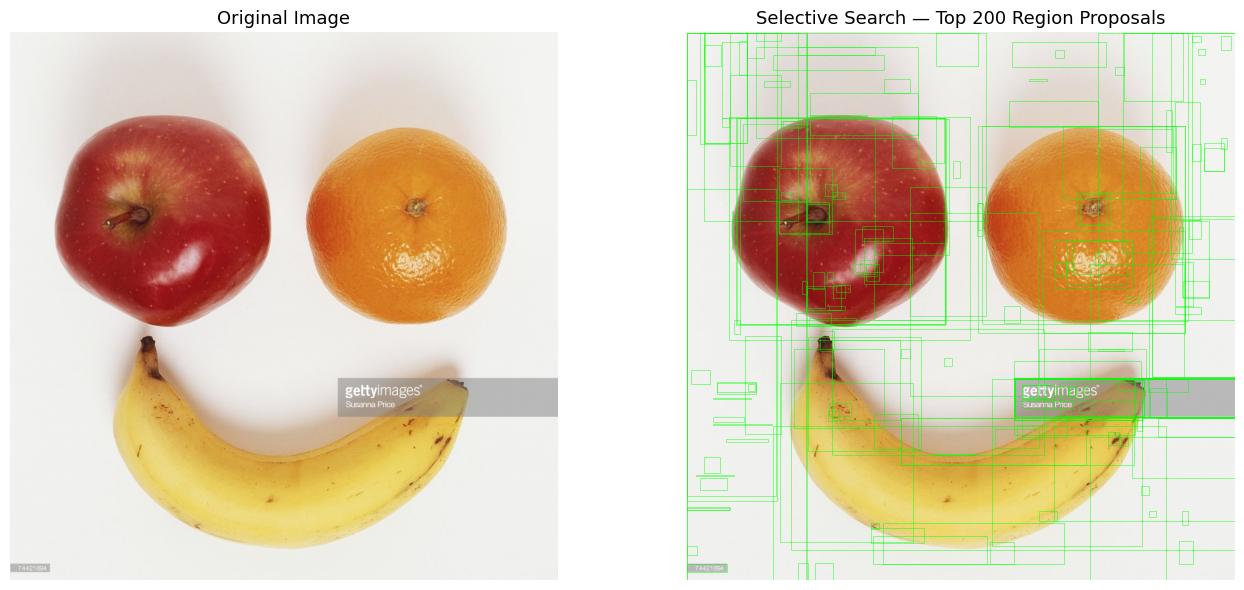

In [9]:
# ─── Visualize 200 region proposals ───
vis_img = img_rgb.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original image
axes[0].imshow(img_rgb)
axes[0].set_title("Original Image", fontsize=13)
axes[0].axis("off")

# Image with proposals
axes[1].imshow(img_rgb)
for (x, y, w, h) in proposals:
    rect = patches.Rectangle((x, y), w, h,
                              linewidth=0.5, edgecolor="lime", facecolor="none", alpha=0.6)
    axes[1].add_patch(rect)
axes[1].set_title(f"Selective Search — Top 200 Region Proposals", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Task 3 - Implementing the R-CNN Bottleneck

In [10]:
import torch
import torchvision.models as models

# ─── Load pretrained ResNet18 and remove final FC layer ───
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# Remove the final classification layer → model now outputs 512-dim feature vectors
feature_extractor = torch.nn.Sequential(*list(resnet18.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print("ResNet18 loaded. Final FC layer removed.")
print(f"Feature extractor output: 512-dim vector per crop")

ResNet18 loaded. Final FC layer removed.
Feature extractor output: 512-dim vector per crop


In [11]:
import torchvision.transforms as T

# ─── Image preprocessing transform ───
preprocess = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

In [12]:
import time

# ─── R-CNN style: crop each proposal, resize, pass through CNN ───
top_100 = proposals[:100]   # Use first 100 proposals from Task 2
h_img, w_img = img_rgb.shape[:2]

features_rcnn = []

print(f"Processing {len(top_100)} crops (R-CNN style)...")
start_time = time.time()

with torch.no_grad():
    for (x, y, w, h) in top_100:
        # Clamp box to image boundaries
        x1 = max(0, x);       y1 = max(0, y)
        x2 = min(w_img, x+w); y2 = min(h_img, y+h)

        # Skip degenerate crops
        if x2 <= x1 or y2 <= y1:
            continue

        crop      = img_rgb[y1:y2, x1:x2]           # Crop region
        tensor    = preprocess(crop).unsqueeze(0).to(device)  # Preprocess
        feat      = feature_extractor(tensor)        # Forward pass
        features_rcnn.append(feat.squeeze().cpu())   # Store feature

end_time = time.time()
rcnn_time = end_time - start_time

print(f"\n{'='*45}")
print(f"  R-CNN: {len(features_rcnn)} crops processed")
print(f"  Total time : {rcnn_time:.4f} seconds")
print(f"  Time/crop  : {rcnn_time/len(features_rcnn)*1000:.2f} ms")
print(f"{'='*45}")

Processing 100 crops (R-CNN style)...

  R-CNN: 100 crops processed
  Total time : 0.5341 seconds
  Time/crop  : 5.34 ms


# Task 4 - Implementing Fast R-CNN (RoI Pooling)

In [13]:
# ─── Build convolutional backbone only (no FC layers) ───
# We strip the AdaptiveAvgPool and FC layer from ResNet18
conv_backbone = torch.nn.Sequential(*list(resnet18.children())[:-2])  # up to layer4
conv_backbone = conv_backbone.to(device)
conv_backbone.eval()

# ─── Preprocess full image ───
img_tensor = preprocess(img_rgb).unsqueeze(0).to(device)  # [1, 3, H, W]

print(f"Input image tensor shape : {img_tensor.shape}")

start_time_fast = time.time()

# ─── Step 1: Single CNN forward pass on the full image ───
with torch.no_grad():
    feature_map = conv_backbone(img_tensor)  # [1, 512, H/32, W/32]

print(f"Feature map shape        : {feature_map.shape}")

# ─── Calculate spatial scale ───
# ResNet18 downsamples by 32x (224 → 7), so spatial_scale = 1/32
input_h = img_tensor.shape[2]
feat_h  = feature_map.shape[2]
spatial_scale = feat_h / input_h
print(f"Spatial scale (stride)   : {spatial_scale:.5f}  (1/{int(1/spatial_scale)})")

Input image tensor shape : torch.Size([1, 3, 224, 224])
Feature map shape        : torch.Size([1, 512, 7, 7])
Spatial scale (stride)   : 0.03125  (1/32)


In [14]:
from torchvision.ops import roi_pool

# ─── Convert top 100 proposals to RoI tensor format ───
# torchvision roi_pool expects [batch_idx, x1, y1, x2, y2]
# Proposals are in (x, y, w, h) — convert to (x1, y1, x2, y2)

roi_list = []
for (x, y, w, h) in top_100:
    x1 = float(max(0, x))
    y1 = float(max(0, y))
    x2 = float(min(w_img, x + w))
    y2 = float(min(h_img, y + h))
    if x2 > x1 and y2 > y1:
        roi_list.append([0, x1, y1, x2, y2])   # batch_idx = 0

rois_tensor = torch.tensor(roi_list, dtype=torch.float32).to(device)
print(f"RoI tensor shape: {rois_tensor.shape}")

# ─── Step 2: RoI Pooling — extract all features in one shot ───
output_size = (feature_map.shape[2], feature_map.shape[3])  # e.g. (7, 7)

with torch.no_grad():
    pooled_features = roi_pool(
        feature_map,
        rois_tensor,
        output_size=output_size,
        spatial_scale=spatial_scale
    )

end_time_fast = time.time()
fast_rcnn_time = end_time_fast - start_time_fast

print(f"Pooled features shape: {pooled_features.shape}")
print(f"\n{'='*45}")
print(f"  Fast R-CNN: {len(roi_list)} RoIs processed")
print(f"  Total time : {fast_rcnn_time:.4f} seconds")
print(f"{'='*45}")

RoI tensor shape: torch.Size([100, 5])
Pooled features shape: torch.Size([100, 512, 7, 7])

  Fast R-CNN: 100 RoIs processed
  Total time : 0.0309 seconds



       EXECUTION TIME COMPARISON
  R-CNN (100 crops)   : 0.5341s  (534.1 ms)
  Fast R-CNN (RoI)    : 0.0309s  (30.9 ms)
  Speedup             : 17.3x faster


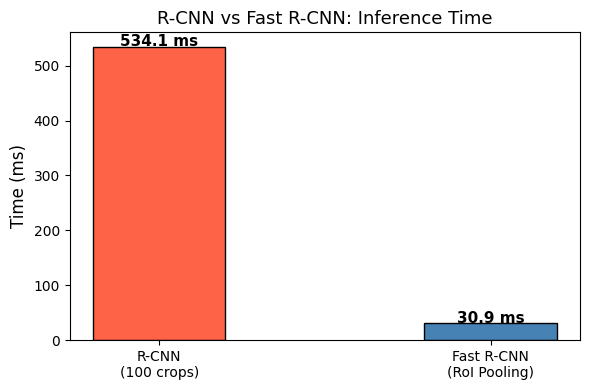

In [15]:
# ─── Comparison: R-CNN vs Fast R-CNN ───
speedup = rcnn_time / fast_rcnn_time

print("\n" + "=" * 50)
print("       EXECUTION TIME COMPARISON")
print("=" * 50)
print(f"  R-CNN (100 crops)   : {rcnn_time:.4f}s  ({rcnn_time*1000:.1f} ms)")
print(f"  Fast R-CNN (RoI)    : {fast_rcnn_time:.4f}s  ({fast_rcnn_time*1000:.1f} ms)")
print(f"  Speedup             : {speedup:.1f}x faster")
print("=" * 50)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(6, 4))
methods = ["R-CNN\n(100 crops)", "Fast R-CNN\n(RoI Pooling)"]
times   = [rcnn_time * 1000, fast_rcnn_time * 1000]
colors  = ["tomato", "steelblue"]
bars    = ax.bar(methods, times, color=colors, width=0.4, edgecolor="black")
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{t:.1f} ms", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Time (ms)", fontsize=12)
ax.set_title("R-CNN vs Fast R-CNN: Inference Time", fontsize=13)
plt.tight_layout()
plt.show()

**Q:  What redundant mathematical operations does Fast R-CNN eliminate to achieve this efficiency?**

In **R-CNN**, every region proposal (e.g. 2000 proposals) is **independently cropped** from the original image, resized to 224×224, and passed through the full CNN backbone. This means the CNN performs a complete forward pass for each crop — even when proposals overlap heavily and their underlying image regions share pixels. This results in massive **redundant computation**: the same pixel values are processed dozens of times.

**Fast R-CNN** eliminates this redundancy by:
1. **Running the CNN only once** on the entire input image to produce a shared feature map.
2. Using **RoI Pooling** to extract fixed-size feature vectors directly from the feature map for each proposal — no repeated CNN passes needed.

The result: the expensive convolutional computation is done exactly **once**, regardless of how many proposals exist, yielding a dramatic speedup (~10–160× depending on number of proposals).

# Task 5 - Faster R-CNN

In [16]:
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn

# ─── Load pretrained Faster R-CNN (COCO weights) ───
faster_rcnn = fasterrcnn_resnet50_fpn(
    weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
)
faster_rcnn = faster_rcnn.to(device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\dhaiv/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [01:32<00:00, 1.81MB/s] 


In [18]:
# COCO class labels (91 classes)
COCO_LABELS = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane',
    'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
    'N/A', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog',
    'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
    'N/A', 'backpack', 'umbrella', 'N/A', 'N/A', 'handbag', 'tie',
    'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite',
    'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
    'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup', 'fork',
    'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
    'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair',
    'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A',
    'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator',
    'N/A', 'book', 'clock', 'vase', 'scissors', 'teddy bear',
    'hair drier', 'toothbrush'
]

In [20]:
# ─── Run inference on the sample image ───
to_tensor = T.ToTensor()
input_tensor = to_tensor(img_rgb).unsqueeze(0).to(device)  # [1, 3, H, W]

faster_rcnn.eval()

with torch.no_grad():
    predictions = faster_rcnn(input_tensor)

pred = predictions[0]
print(f"Total predictions before filtering: {len(pred['boxes'])}")

Total predictions before filtering: 6


In [21]:
def filter_predictions(pred, threshold=0.80):
    """
    Filter out bounding box predictions below a confidence threshold.

    Parameters
    ----------
    pred      : dict with keys 'boxes', 'labels', 'scores'
    threshold : float, minimum confidence score to keep

    Returns
    -------
    filtered dict with only high-confidence predictions
    """
    keep = pred["scores"] >= threshold
    return {
        "boxes":  pred["boxes"][keep],
        "labels": pred["labels"][keep],
        "scores": pred["scores"][keep]
    }

In [22]:
filtered = filter_predictions(pred, threshold=0.80)
print(f"Predictions after filtering (≥0.80): {len(filtered['boxes'])}")
for i, (box, lbl, scr) in enumerate(zip(filtered["boxes"], filtered["labels"], filtered["scores"])):
    label_name = COCO_LABELS[lbl.item()] if lbl.item() < len(COCO_LABELS) else str(lbl.item())
    print(f"  [{i+1}] {label_name:15s} | Score: {scr:.3f} | Box: {box.cpu().numpy().astype(int)}")

Predictions after filtering (≥0.80): 3
  [1] banana          | Score: 0.998 | Box: [198 564 857 964]
  [2] orange          | Score: 0.995 | Box: [549 178 934 553]
  [3] apple           | Score: 0.985 | Box: [ 78 147 492 551]


C:\Users\dhaiv\AppData\Local\Temp\ipykernel_2984\969914909.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Set1", max(len(filtered["boxes"]), 1))


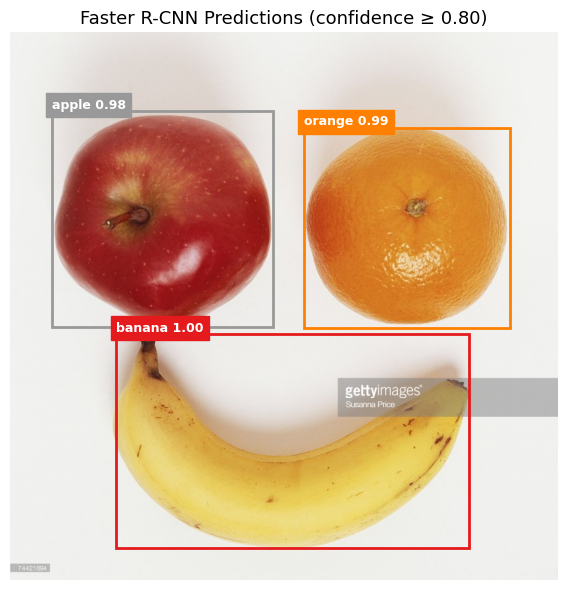

In [23]:
# ─── Visualize Faster R-CNN predictions ───
fig, ax = plt.subplots(1, figsize=(8, 6))
ax.imshow(img_rgb)

cmap = plt.cm.get_cmap("Set1", max(len(filtered["boxes"]), 1))

for i, (box, lbl, scr) in enumerate(zip(filtered["boxes"], filtered["labels"], filtered["scores"])):
    x1, y1, x2, y2 = box.cpu().numpy().astype(int)
    label_name = COCO_LABELS[lbl.item()] if lbl.item() < len(COCO_LABELS) else str(lbl.item())
    color = cmap(i)

    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                              linewidth=2, edgecolor=color, facecolor="none")
    ax.add_patch(rect)
    ax.text(x1, y1 - 5, f"{label_name} {scr:.2f}",
            fontsize=9, color="white", backgroundcolor=color, fontweight="bold")

ax.set_title("Faster R-CNN Predictions (confidence ≥ 0.80)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

**Q: Faster R-CNN introduced the Region Proposal Network (RPN). How does the RPN eliminate the need for external algorithms like Selective Search?**

**Selective Search** is an external, hand-crafted algorithm that analyzes pixel-level similarity, texture, color, and size to group regions into proposals. It runs *outside* the neural network, is not learned from data, and cannot be optimized jointly with the detector.

The **Region Proposal Network (RPN)** introduced in Faster R-CNN solves this by:
1. **Sharing the convolutional backbone** it slides a small network over the *same feature map* already computed by the detector backbone, adding near-zero extra computation.
2. **Using anchor boxes** at each spatial location in the feature map, the RPN predicts objectness scores and box offsets for a set of pre-defined anchors (multiple scales and aspect ratios).
3. **Being fully learnable,** the RPN is trained end-to-end with the detector using gradient descent, so it learns to propose regions that are actually useful for the downstream classifier.

The result is a unified, data-driven pipeline where proposal generation and object classification share computation and are jointly optimized, making Faster R-CNN both faster and more accurate than its predecessors.

# Task 6 - Non-Maximum Suppression (NMS) 

In [24]:
def non_maximum_suppression(boxes, scores, iou_threshold=0.5):
    """
    Custom Non-Maximum Suppression (NMS) implementation.

    Algorithm:
    1. Sort boxes by confidence score (descending).
    2. Select the box with the highest score → final prediction.
    3. Discard any remaining boxes with IoU > threshold relative to the selected box.
    4. Repeat until no unchecked boxes remain.

    Parameters
    ----------
    boxes         : list of [x_min, y_min, x_max, y_max]
    scores        : list of confidence scores (same length as boxes)
    iou_threshold : float, boxes with IoU above this are discarded

    Returns
    -------
    kept_boxes  : list of surviving bounding boxes
    kept_scores : list of their scores
    kept_indices: list of their original indices
    """
    if len(boxes) == 0:
        return [], [], []

    # Sort indices by score, highest first
    order = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)

    kept_indices = []

    while order:
        # Always pick the highest-scoring remaining box
        best = order[0]
        kept_indices.append(best)
        order = order[1:]  # Remove the picked box from consideration

        # Filter remaining boxes by IoU with the selected box
        remaining = []
        for idx in order:
            iou = compute_iou(boxes[best], boxes[idx])
            if iou <= iou_threshold:
                remaining.append(idx)  # Keep boxes that don't overlap much
        order = remaining

    kept_boxes  = [boxes[i]  for i in kept_indices]
    kept_scores = [scores[i] for i in kept_indices]
    return kept_boxes, kept_scores, kept_indices

In [25]:
# ─── Demonstration on synthetic boxes ───
demo_boxes = [
    [100, 100, 200, 200],   # Box 0 — high confidence, will be kept
    [105, 105, 205, 205],   # Box 1 — overlaps heavily with 0 → discarded
    [110, 108, 210, 208],   # Box 2 — overlaps with 0 → discarded
    [300, 300, 400, 400],   # Box 3 — separate object → kept
    [305, 305, 405, 405],   # Box 4 — overlaps with 3 → discarded
]
demo_scores = [0.95, 0.88, 0.76, 0.91, 0.70]

kept_b, kept_s, kept_i = non_maximum_suppression(demo_boxes, demo_scores, iou_threshold=0.5)

print("NMS Demonstration")
print(f"  Input boxes : {len(demo_boxes)}")
print(f"  After NMS   : {len(kept_b)} boxes kept")
print(f"  Kept indices: {kept_i}")
for b, s in zip(kept_b, kept_s):
    print(f"    Box {b}  Score: {s:.2f}")

NMS Demonstration
  Input boxes : 5
  After NMS   : 2 boxes kept
  Kept indices: [0, 3]
    Box [100, 100, 200, 200]  Score: 0.95
    Box [300, 300, 400, 400]  Score: 0.91


**Q: The IoU threshold acts as a strictness dial for discarding duplicate bounding boxes. If you are trying to detect a cluster of tightly packed objects (e.g., several apples piled together in a basket), how would setting the IoU threshold extremely high (0.9) versus extremely low (0.1) alter your final visual predictions? Explain why.**

The IoU threshold controls how aggressively NMS suppresses overlapping boxes:

- **High threshold (e.g. 0.9):** A box is only discarded if it overlaps *extremely heavily* with a selected box. For tightly packed apples in a basket, each apple's box overlaps moderately but not almost entirely with neighboring boxes. A threshold of 0.9 means NMS will **keep most of the duplicate boxes** (since their IoU < 0.9), resulting in **multiple detections per apple,** many false positives.

- **Low threshold (e.g. 0.1):** Even slightly overlapping boxes are suppressed. For tightly packed fruits whose bounding boxes naturally overlap a little just due to proximity, NMS will **merge too aggressively,** discarding valid boxes for distinct nearby fruits. You end up with **missed detections,** one box for what should be multiple fruit detections.

**Best practice:** For dense, overlapping objects, a moderate threshold (~0.4–0.5) works well. For sparse, well-separated objects, a lower threshold suffices. Specialized techniques like **Soft-NMS** decay scores rather than hard-discarding, offering a better trade-off for crowded scenes.

# Task 7 - YOLO Fine-Tuning